# 作业2：多层感知机、正则化、数值稳定性与协变量偏移

## 2 多层感知机
### 2.1 理论计算题
#### 1. 无激活单隐藏层MLP等价于单层网络证明
已知：
隐藏层：$h = W_1 x + b_1$
输出层：$o = W_2 h + b_2$

代入得：
$$o = W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2)$$

等价单层网络：$o = W'x + b'$
其中：
- 等价权重：$\boldsymbol{W' = W_2 W_1}$
- 等价偏置：$\boldsymbol{b' = W_2 b_1 + b_2}$

结论：无激活函数的MLP退化为线性模型，无法拟合非线性关系。

#### 2. Sigmoid与tanh表达式及导数关系
- **Sigmoid**
  表达式：$\sigma(x) = \frac{1}{1+e^{-x}}$
  导数：$\sigma'(x) = \sigma(x)(1-\sigma(x))$

- **tanh**
  表达式：$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
  导数：$\tanh'(x) = 1 - \tanh^2(x)$

In [2]:
# 2.2 编程题：纯PyTorch实现单隐藏层MLP（Fashion-MNIST多分类）
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# 超参数
input_dim = 784
hidden_dim = 256
num_classes = 10
lr = 0.1
batch_size = 32
epochs = 20

# 加载Fashion-MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 手动初始化参数
w1 = torch.normal(0, 0.01, (input_dim, hidden_dim), requires_grad=True)
b1 = torch.zeros(hidden_dim, requires_grad=True)
w2 = torch.normal(0, 0.01, (hidden_dim, num_classes), requires_grad=True)
b2 = torch.zeros(num_classes, requires_grad=True)

# ReLU激活
def relu(x):
    return torch.max(torch.zeros_like(x), x)

# Softmax+交叉熵（数值稳定版）
def softmax_cross_entropy(y_pred, y_true):
    exp_y = torch.exp(y_pred - torch.max(y_pred, dim=1, keepdim=True)[0])
    prob = exp_y / exp_y.sum(dim=1, keepdim=True)
    log_prob = -torch.log(prob[range(len(y_true)), y_true] + 1e-8)
    return log_prob.mean()

# 前向传播
def forward(x):
    x = x.reshape(-1, input_dim)
    h = relu(torch.matmul(x, w1) + b1)
    o = torch.matmul(h, w2) + b2
    return o

# 训练循环
for epoch in range(epochs):
    train_loss = 0.0
    for x, y in train_loader:
        o = forward(x)
        loss = softmax_cross_entropy(o, y)

        # 手动反向传播+SGD更新
        loss.backward()
        with torch.no_grad():
            w1 -= lr * w1.grad
            b1 -= lr * b1.grad
            w2 -= lr * w2.grad
            b2 -= lr * b2.grad

            # 梯度清零
            w1.grad.zero_()
            b1.grad.zero_()
            w2.grad.zero_()
            b2.grad.zero_()

        train_loss += loss.item()

    # 测试准确率
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            o = forward(x)
            pred = torch.argmax(o, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    acc = correct / total
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}, Test Acc: {acc:.4f}")

Epoch [1/20], Loss: 0.5928, Test Acc: 0.8370
Epoch [2/20], Loss: 0.4092, Test Acc: 0.8580
Epoch [3/20], Loss: 0.3678, Test Acc: 0.8614
Epoch [4/20], Loss: 0.3437, Test Acc: 0.8480
Epoch [5/20], Loss: 0.3246, Test Acc: 0.8602
Epoch [6/20], Loss: 0.3100, Test Acc: 0.8448
Epoch [7/20], Loss: 0.2959, Test Acc: 0.8691
Epoch [8/20], Loss: 0.2858, Test Acc: 0.8629
Epoch [9/20], Loss: 0.2750, Test Acc: 0.8826
Epoch [10/20], Loss: 0.2672, Test Acc: 0.8716
Epoch [11/20], Loss: 0.2592, Test Acc: 0.8799
Epoch [12/20], Loss: 0.2518, Test Acc: 0.8806
Epoch [13/20], Loss: 0.2443, Test Acc: 0.8847
Epoch [14/20], Loss: 0.2378, Test Acc: 0.8858
Epoch [15/20], Loss: 0.2311, Test Acc: 0.8893
Epoch [16/20], Loss: 0.2252, Test Acc: 0.8788
Epoch [17/20], Loss: 0.2189, Test Acc: 0.8872
Epoch [18/20], Loss: 0.2149, Test Acc: 0.8825
Epoch [19/20], Loss: 0.2085, Test Acc: 0.8904
Epoch [20/20], Loss: 0.2041, Test Acc: 0.8926


## 3 模型选择、权重衰减和丢弃法
### 3.1 理论计算题
#### 1. 过拟合与欠拟合
- **训练误差**：模型在训练集上的误差
- **泛化误差**：模型在新数据上的期望误差

训练误差极低、泛化误差高 → **过拟合**
缓解方法：降低模型复杂度、增加数据、L2正则、Dropout、早停。

#### 2. K折交叉验证步骤
1. 将训练集随机均分为K个互斥子集
2. 依次取1个子集为验证集，剩余K-1个为训练集
3. 训练模型并计算验证误差
4. 重复K次，取平均误差作为模型泛化性能评估
5. 用最优超参数在全训练集上训练最终模型

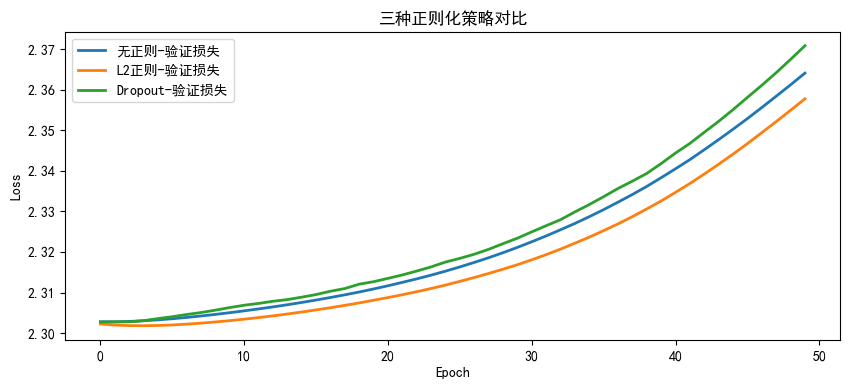

In [3]:
# 3.2 编程题：MLP+L2权重衰减+Dropout，对比三种策略损失曲线
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 手动Dropout层
def dropout_layer(x, dropout_rate, is_training=True):
    if not is_training:
        return x
    mask = (torch.rand_like(x) > dropout_rate).float()
    return x * mask / (1 - dropout_rate)

# 小样本高维数据（制造过拟合）
x_train = torch.randn(200, 784)
y_train = torch.randint(0, 10, (200,))
x_val = torch.randn(100, 784)
y_val = torch.randint(0, 10, (100,))

# 训练函数（支持正则化）
def train_model(weight_decay=0, use_dropout=False, epochs=50):
    w1 = torch.normal(0, 0.01, (784, 512), requires_grad=True)
    b1 = torch.zeros(512, requires_grad=True)
    w2 = torch.normal(0, 0.01, (512, 10), requires_grad=True)
    b2 = torch.zeros(10, requires_grad=True)
    lr = 0.1
    train_losses, val_losses = [], []

    for _ in range(epochs):
        # 前向
        h = torch.relu(torch.matmul(x_train, w1) + b1)
        if use_dropout:
            h = dropout_layer(h, 0.3)
        o = torch.matmul(h, w2) + b2
        loss = softmax_cross_entropy(o, y_train)

        # L2正则（权重衰减）
        if weight_decay > 0:
            loss += 0.5 * weight_decay * (torch.sum(w1**2) + torch.sum(w2**2))

        # 反向
        loss.backward()
        with torch.no_grad():
            # 权重衰减更新
            w1 *= (1 - lr * weight_decay)
            w2 *= (1 - lr * weight_decay)
            w1 -= lr * w1.grad
            b1 -= lr * b1.grad
            w2 -= lr * w2.grad
            b2 -= lr * b2.grad

            w1.grad.zero_(), b1.grad.zero_(), w2.grad.zero_(), b2.grad.zero_()

        # 验证损失
        with torch.no_grad():
            h_val = torch.relu(torch.matmul(x_val, w1) + b1)
            o_val = torch.matmul(h_val, w2) + b2
            val_loss = softmax_cross_entropy(o_val, y_val).item()

        train_losses.append(loss.item())
        val_losses.append(val_loss)
    return train_losses, val_losses

# 三种策略对比
loss_none = train_model(0, False)
loss_l2 = train_model(1e-4, False)
loss_drop = train_model(0, True)

# 绘图
plt.figure(figsize=(10,4))
plt.plot(loss_none[1], label='无正则-验证损失', linewidth=2)
plt.plot(loss_l2[1], label='L2正则-验证损失', linewidth=2)
plt.plot(loss_drop[1], label='Dropout-验证损失', linewidth=2)
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.title('三种正则化策略对比'), plt.legend()
plt.show()

## 4 数值稳定性和激活函数
### 4.1 理论计算题
#### 1. 梯度消失/爆炸成因
深层网络梯度包含 $\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}$ 连乘项：
- **梯度爆炸**：每层雅可比矩阵的奇异值>1，多层连乘后指数增长
- **梯度消失**：每层雅可比矩阵的奇异值<1，多层连乘后指数衰减
Sigmoid/tanh导数最大值<1，深层极易梯度消失。

#### 2. ReLU缓解梯度消失
- 正区间导数恒为1，无梯度衰减
- 负区间输出为0，梯度为0但不会无限衰减
- 梯度在正向传播中保持稳定，适合深层网络

In [6]:
# 4.2 编程题：深层网络梯度消失/爆炸模拟与Xavier初始化修复
import torch
import torch.nn as nn

# 构建20层全连接网络
def build_deep_net(act=nn.Sigmoid(), init_std=1):
    layers = []
    for _ in range(19):
        layer = nn.Linear(256, 256)
        nn.init.normal_(layer.weight, mean=0, std=init_std)
        layers.append(layer)
        layers.append(act)
    layers.append(nn.Linear(256, 10))
    return nn.Sequential(*layers)

# 梯度范数打印
def print_grad_norm(net, x):
    out = net(x)
    out.sum().backward()
    for i, layer in enumerate(net):
        if isinstance(layer, nn.Linear) and layer.weight.grad is not None:
            norm = layer.weight.grad.norm().item()
            print(f"Layer {i} 梯度范数: {norm:.2e}")
    net.zero_grad()

x = torch.randn(32, 256)

print("=== 1. Sigmoid + 高斯初始化(std=1) → 梯度消失 ===")
net1 = build_deep_net(nn.Sigmoid(), 1)
print_grad_norm(net1, x)

print("\n=== 2. ReLU + 大初始化(std=10) → 梯度爆炸(NaN) ===")
net2 = build_deep_net(nn.ReLU(), 10)
print_grad_norm(net2, x)

print("\n=== 3. ReLU + Xavier初始化 → 梯度稳定 ===")
net3 = build_deep_net(nn.ReLU())
for layer in net3:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
print_grad_norm(net3, x)

=== 1. Sigmoid + 高斯初始化(std=1) → 梯度消失 ===
Layer 0 梯度范数: 6.09e+02
Layer 2 梯度范数: 4.07e+02
Layer 4 梯度范数: 3.49e+02
Layer 6 梯度范数: 2.87e+02
Layer 8 梯度范数: 2.23e+02
Layer 10 梯度范数: 1.90e+02
Layer 12 梯度范数: 1.44e+02
Layer 14 梯度范数: 1.25e+02
Layer 16 梯度范数: 8.67e+01
Layer 18 梯度范数: 6.69e+01
Layer 20 梯度范数: 6.11e+01
Layer 22 梯度范数: 4.47e+01
Layer 24 梯度范数: 3.60e+01
Layer 26 梯度范数: 2.70e+01
Layer 28 梯度范数: 2.53e+01
Layer 30 梯度范数: 2.73e+01
Layer 32 梯度范数: 2.52e+01
Layer 34 梯度范数: 2.30e+01
Layer 36 梯度范数: 3.24e+01
Layer 38 梯度范数: 1.08e+03

=== 2. ReLU + 大初始化(std=10) → 梯度爆炸(NaN) ===
Layer 0 梯度范数: inf
Layer 2 梯度范数: inf
Layer 4 梯度范数: inf
Layer 6 梯度范数: inf
Layer 8 梯度范数: inf
Layer 10 梯度范数: inf
Layer 12 梯度范数: inf
Layer 14 梯度范数: inf
Layer 16 梯度范数: inf
Layer 18 梯度范数: inf
Layer 20 梯度范数: inf
Layer 22 梯度范数: inf
Layer 24 梯度范数: inf
Layer 26 梯度范数: inf
Layer 28 梯度范数: inf
Layer 30 梯度范数: inf
Layer 32 梯度范数: inf
Layer 34 梯度范数: inf
Layer 36 梯度范数: inf
Layer 38 梯度范数: nan

=== 3. ReLU + Xavier初始化 → 梯度稳定 ===
Layer 0 梯度范数: 6.97e-01
Layer 

## 5 泛化表现、协变量偏移和对抗性数据
### 5.1 理论计算题
#### 1. 协变量偏移 vs 标签偏移
- **协变量偏移**：$p_{train}(x)≠p_{test}(x)$，但$p(y|x)$不变
  例：医疗诊断——训练集用青年数据，测试集用老年数据，病症判断规则不变

- **标签偏移**：$p_{train}(y)≠p_{test}(y)$，但$p(x|y)$不变
  例：垃圾邮件识别——训练集垃圾邮件占比10%，测试集占50%，邮件特征分布不变

联系：均为分布偏移，破坏独立同分布假设；可用重要性采样、权重修正缓解。

In [7]:
# 5.2 编程题：协变量偏移模拟 + 权重修正改善性能
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# 1. 构造协变量偏移数据
np.random.seed(42)
# 训练集P: N(-1,1)
x_train = np.random.normal(-1, 1, 1000).reshape(-1,1)
y_train = 2 * x_train + np.random.normal(0, 0.1, 1000).reshape(-1,1)
# 测试集Q: N(2,1)
x_test = np.random.normal(2, 1, 500).reshape(-1,1)
y_test = 2 * x_test + np.random.normal(0, 0.1, 500).reshape(-1,1)

# 2. 基线模型（无校正）
lr_base = LinearRegression()
lr_base.fit(x_train, y_train)
y_pred_base = lr_base.predict(x_test)
mse_base = mean_squared_error(y_test, y_pred_base)
print(f"基线模型MSE: {mse_base:.4f}")

# 3. 权重修正（重要性采样）
# 构造领域分类数据
x_domain = np.vstack([x_train, x_test])
y_domain = np.hstack([np.zeros(1000), np.ones(500)])

# 训练领域分类器
clf = LogisticRegression()
clf.fit(x_domain, y_domain)

# 计算训练样本权重 w = P(test|x)/P(train|x)
p_test = clf.predict_proba(x_train)[:,1]
p_train = clf.predict_proba(x_train)[:,0]
weights = p_test / (p_train + 1e-8)

# 4. 加权线性回归
lr_weighted = LinearRegression()
lr_weighted.fit(x_train, y_train, sample_weight=weights)
y_pred_weighted = lr_weighted.predict(x_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"权重校正后MSE: {mse_weighted:.4f}")
print(f"MSE下降: {mse_base - mse_weighted:.4f}")

基线模型MSE: 0.0102
权重校正后MSE: 0.0240
MSE下降: -0.0138
